# **Assignment 9: Introduction To CNN Models**

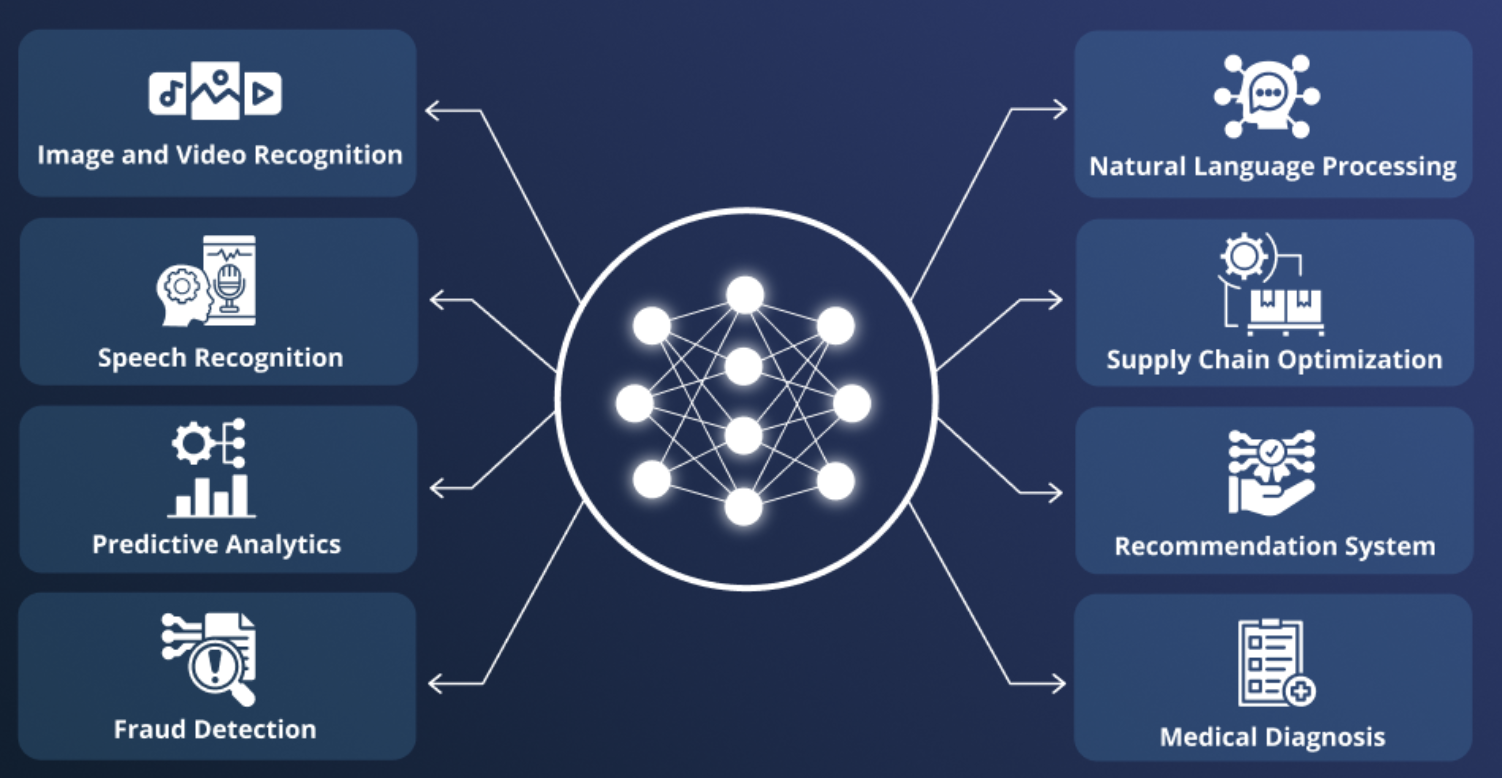

# **Image Classification**

**Goal:** Build a DL-based for Digit Classification on Street View House Numbers dataset.  

**Street View House Numbers (SVHN**) is a digit classification benchmark dataset that contains 600,000 32×32 RGB images of printed digits (from 0 to 9) cropped from pictures of house number plates. The cropped images are centered in the digit of interest, but nearby digits and other distractors are kept in the image. SVHN has three sets: training, testing sets and an extra set with 530,000 images that are less difficult and can be used for helping with the training process.

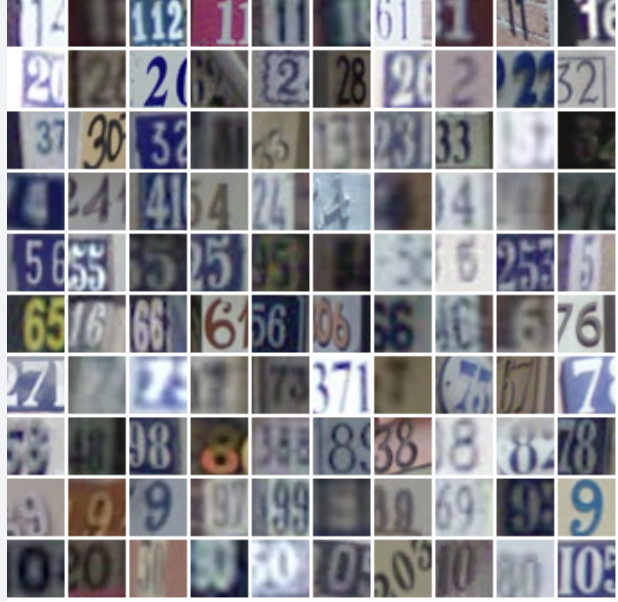

**Question 1:** Load the images from file. Present the number of training, testing and Validation samples. Also, show the Image Dimensions, labels, and image formats.

In [1]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Transform images to tensors
transform = transforms.ToTensor()

# Load datasets
train_set = datasets.SVHN(root=r'C:\Users\rajiv\Documents\Masters\Classes\ML\images', split='train', download=True, transform=transform)
test_set = datasets.SVHN(root=r'C:\Users\rajiv\Documents\Masters\Classes\ML\images', split='test', download=True, transform=transform)
extra_set = datasets.SVHN(root=r'C:\Users\rajiv\Documents\Masters\Classes\ML\images', split='extra', download=True, transform=transform)


Using downloaded and verified file: C:\Users\rajiv\Documents\Masters\Classes\ML\images\train_32x32.mat
Using downloaded and verified file: C:\Users\rajiv\Documents\Masters\Classes\ML\images\test_32x32.mat
Using downloaded and verified file: C:\Users\rajiv\Documents\Masters\Classes\ML\images\extra_32x32.mat


Loads datasets accordingly

In [2]:
# Num of Training, Testing and Extra samples
print("Number of training samples:", len(train_set))
print("Number of testing samples:", len(test_set))
print("Number of extra samples:", len(extra_set))

Number of training samples: 73257
Number of testing samples: 26032
Number of extra samples: 531131


Number of samples for each dataset listed

In [3]:
# Dimensions labls and Image formats:
# Inspect one image and label
seen_labels = set()

print("Unique label samples in training set:")
for img, label in train_set:
    if label not in seen_labels:
        seen_labels.add(label)
        print(f"Label: {label}, Image shape: {img.shape}, Format: {img.dtype}")
    if len(seen_labels) == 10:
        break
        
print("Image format: RGB (3-channel)")

Unique label samples in training set:
Label: 1, Image shape: torch.Size([3, 32, 32]), Format: torch.float32
Label: 9, Image shape: torch.Size([3, 32, 32]), Format: torch.float32
Label: 2, Image shape: torch.Size([3, 32, 32]), Format: torch.float32
Label: 3, Image shape: torch.Size([3, 32, 32]), Format: torch.float32
Label: 5, Image shape: torch.Size([3, 32, 32]), Format: torch.float32
Label: 8, Image shape: torch.Size([3, 32, 32]), Format: torch.float32
Label: 7, Image shape: torch.Size([3, 32, 32]), Format: torch.float32
Label: 4, Image shape: torch.Size([3, 32, 32]), Format: torch.float32
Label: 6, Image shape: torch.Size([3, 32, 32]), Format: torch.float32
Label: 0, Image shape: torch.Size([3, 32, 32]), Format: torch.float32
Image format: RGB (3-channel)


Labels shapes and format for each datatset loaded accurately.

**Question 2:** Using Keras or PyTorch, clean, normalize, and re-shape the data for the model input.

In [4]:
from torchvision import transforms, datasets
from torch.utils.data import ConcatDataset, random_split
import warnings
warnings.filterwarnings('ignore')

transform = transforms.Compose([
    transforms.ToTensor(),  
    transforms.Normalize(mean=[0.5, 0.5, 0.5], 
                         std=[0.5, 0.5, 0.5])  
])

train_set = datasets.SVHN(root=r'C:\Users\rajiv\Documents\Masters\Classes\ML\images', split='train', download=True, transform=transform)
test_set = datasets.SVHN(root=r'C:\Users\rajiv\Documents\Masters\Classes\ML\images', split='test', download=True, transform=transform)
extra_set = datasets.SVHN(root=r'C:\Users\rajiv\Documents\Masters\Classes\ML\images', split='extra', download=True, transform=transform)

# Combine train + extra
full_train = ConcatDataset([train_set, extra_set])

# Create validation split: 10% of full training data
val_size = int(0.1 * len(full_train))
train_size = len(full_train) - val_size

# Randomly splits to make train and validation sets:
train_set, val_set = random_split(full_train, [train_size, val_size])

# Updated dataset sizes
print("Training set size:", len(train_set))
print("Validation set size:", len(val_set))
print("Test set size:", len(test_set))

# Look at one sample, different as we've now described validation set
sample_img, sample_label = train_set[0]
print("Sample image shape (C,H,W):", sample_img.shape)
print("Tensor dtype:", sample_img.dtype)
print("Sample label:", sample_label)

Using downloaded and verified file: C:\Users\rajiv\Documents\Masters\Classes\ML\images\train_32x32.mat
Using downloaded and verified file: C:\Users\rajiv\Documents\Masters\Classes\ML\images\test_32x32.mat
Using downloaded and verified file: C:\Users\rajiv\Documents\Masters\Classes\ML\images\extra_32x32.mat
Training set size: 543950
Validation set size: 60438
Test set size: 26032
Sample image shape (C,H,W): torch.Size([3, 32, 32])
Tensor dtype: torch.float32
Sample label: 3


Applied normalization to the dataset. Shape is in correct format. We combine train and extra to make our validation set because extra is not the validation set alone.

**Question 3:** Data augmentation in deep learning is a technique to artificially expand a dataset by creating modified copies of existing data, thereby increasing the size and diversity of the training set. This process improves model performance by enhancing generalizability and reducing overfitting, as it allows the model to encounter a wider range of real-world variations. Common methods include geometric transformations (like image rotation and flips), color space transformations (adjusting brightness, contrast), and random erasing.

Apply any Data Augmentation to increase the variety of training examples, lead to help the model generalize better. Provide the description of apparoch and the importance of data augmentation in DL process.


In [5]:
from torchvision import transforms
from torchvision import datasets
from torch.utils.data import ConcatDataset, random_split
import warnings
warnings.filterwarnings('ignore')

train_transform = transforms.Compose([
    # Data Augmentation by Random Cropping
    transforms.RandomCrop(32, padding=4),
    
    # Data Augmentation by Flipping
    transforms.RandomHorizontalFlip(),
    
    # Data Augmentation by Color Jittering
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    
    # Convert image to tensor
    transforms.ToTensor(),
    
    # Normalization
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

# Load training + extra with augmentation
train_set = datasets.SVHN(root=r'C:\Users\rajiv\Documents\Masters\Classes\ML\images', split='train', download=True, transform=train_transform)
extra_set = datasets.SVHN(root=r'C:\Users\rajiv\Documents\Masters\Classes\ML\images', split='extra', download=True, transform=train_transform)
full_train = ConcatDataset([train_set, extra_set])

# Make validation set as in step 2
val_size = int(0.1 * len(full_train))
train_size = len(full_train) - val_size
train_set, val_set = random_split(full_train, [train_size, val_size])

# Transform for validation set and test set
val_set.dataset.transform = val_test_transform
test_set = datasets.SVHN(root=r'C:\Users\rajiv\Documents\Masters\Classes\ML\images', split='test', download=True, transform=val_test_transform)


Using downloaded and verified file: C:\Users\rajiv\Documents\Masters\Classes\ML\images\train_32x32.mat
Using downloaded and verified file: C:\Users\rajiv\Documents\Masters\Classes\ML\images\extra_32x32.mat
Using downloaded and verified file: C:\Users\rajiv\Documents\Masters\Classes\ML\images\test_32x32.mat


Composed a set of transformations for training data through applying Random Cropping, Random Flips, color jittering and then converting image to tensor. Normal transformation applied for both validation and test set. Data augmentation is only to be applied to training set. Random cropping slightly shifts positions of images. Random horizontal flip creates a mirror image of a sample image by flipping it horizontally for 50% of the picutres it is applied to. Color jitter randomly changes the brightness, contrast, saturation, and hue of the images.

Data augementation is important becuase it simulates real world situations where images might not appear consistently each time even though they are taken of the same subject. For example, a street sign might have varying lighting, angles etc in which these augmentations and transformations help to reflect. The model being trained on these images and for it to recognize them as the same helps it to be more robust in the future. 

**Question 4:** Normalize, reshape, and encode the data to make it ready for classification.
Also, what is data batching and why we need it? perform it.

Normalization, reshaping and encoding are already handled by transforms.ToTensor() as part of PyTorch so no extra work is neede there. Proceeding to data batching step.

In [6]:
from torch.utils.data import DataLoader
batch_size = 64

# Training DataLoader
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2)

# Validation DataLoader
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2)

# Test DataLoader
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2)

Data batching is when training examples are grouped together into batches as opposed to feeding the whole dataset into the NN or one NN at a time. Batches are a good inbetween because it helps improve computational time as modern GPUs can process samples simultaneously. It also makes it so that memory isn't overloaded by loading an entire dataset at once. Batches help regulate the amount thats loaded at once.

**Question 5:** Using Keras/PyTorch, implement the Simple CNN and AlexNet to classify different didgits. Provide the details of the proposed architecture for both CNN and AlexNet.


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        
        # Convultional block with 32 channels
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size =3, padding =1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.MaxPool2d(2)
        )
        
        # Convolutional block 2: 32->64 channels
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.MaxPool2d(2)
        )
        
        # Fully Connected Block
        # 4096 = 64 channels × 8 height × 8 width
        self.fc_block = nn.Sequential(
            nn.Linear(64*8*8, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        # Input: (batch, 256) → Output: (batch, 10)
        self.output = nn.Linear(256, num_classes)
        
    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = x.view(x.size(0), -1)
        x = self.fc_block(x)
        return self.output(x)
        

The SimpleCNN is a CNN with 2 convolutional blocks and fully connected layers. The first convolutional block  takes 32 feature maps from teh input and reduces dimensions to 16 * 16 with map pooling. The second block increases the feature depth to 64 channels and reduces dimensions to 8x8. Each block has batch normalization for stability and reLU for non-linearity and 10% dropout to apply regularization. The final layer is then used for digit classification.

In [8]:
class AlexNetSVHN(nn.Module):
    def __init__(self, num_classes=10):
        super(AlexNetSVHN, self).__init__()
        
        self.features=nn.Sequential(
            # Conv Layer 1: 3→64 channels, maintains 32×32
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            # Conv Layer 2: 64→192 channels, maintains 16×16
            nn.Conv2d(64, 192, kernel_size=3, padding=1),
            nn.BatchNorm2d(192),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            # Conv Layer 3: 192→384 channels, maintains 8×8
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(),
            
            # Conv Layer 4: 384→256 channels, maintains 8×8
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            
            # Conv Layer 5: 256→256 channels, maintains 8×8
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        # Classification: 3 Fully Connected Layers
        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(256*4*4, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

This consists of 5 convolution layers followed by three fully connected layers. The first 2 blocks are followed by max pooling which reduces spacial dimensions from 32 halfing each time till it reaches 8x8. Batch normalization is used after the first 2 layers to maintain stability. Three more layers extract complex features at 9x9 before max pooling reduces dimensions further to 4x4. The flattened 4096-dimension feature bector is processed through 3 fully conneccted layers with the same batch normalization, ReLU usage and dropout between layers to prevent overfitting. The final layer is then used for digit classification. 

In [16]:
import torch.optim as optim
# Tells the device to be set to GPU, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

simple_model = SimpleCNN().to(device)
alexnet_model = AlexNetSVHN().to(device)

# Optimization as required
criterion = nn.CrossEntropyLoss()
optimizer_simple = optim.Adam(simple_model.parameters(), lr=0.001)
optimizer_alexnet = optim.Adam(alexnet_model.parameters(), lr=0.001)

Optimizes as needed for next step

**Question 6**: Train and evaluate the model in terms of accuracy, training time per sample, f1, precison, recall and loss. Donot forget to prevent over fitting issues, using batch normalization, drop out, and other regularization techniques. Also be sure your model is optimized.


**********************


In [10]:
import time
from sklearn.metrics import f1_score, precision_score, recall_score

# Pytorch to go through training set 10 times
num_epochs = 10

def train_model(model, train_loader, val_loader, criterion, optimizer, device):
    train_losses, val_losses = [], []
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        start_time = time.time()
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() *images.size(0)
            
        epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)
        
        model.eval()
        val_loss = 0.0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                
                preds = outputs.argmax(dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                
            val_loss /= len(val_loader.dataset)
            val_losses.append(val_loss)
            
            # Metrics
            f1 = f1_score(all_labels, all_preds, average='weighted')
            precision = precision_score(all_labels, all_preds, average='weighted')
            recall = recall_score(all_labels, all_preds, average='weighted')
            epoch_time = (time.time() - start_time)/len(train_loader.dataset)
            
            print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {epoch_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"F1: {f1:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | "
              f"Time per sample: {epoch_time:.6f}s")
        
    return train_losses, val_losses

In [11]:
# Train Simple CNN
train_losses_simple, val_losses_simple = train_model(
    simple_model, train_loader, val_loader, criterion, optimizer_simple, device
)

# Train AlexNet
train_losses_alex, val_losses_alex = train_model(
    alexnet_model, train_loader, val_loader, criterion, optimizer_alexnet, device
)

Epoch 1/10 | Train Loss: 0.5760 | Val Loss: 0.3107 | F1: 0.9106 | Precision: 0.9115 | Recall: 0.9108 | Time per sample: 0.000399s
Epoch 2/10 | Train Loss: 0.3393 | Val Loss: 0.2436 | F1: 0.9307 | Precision: 0.9313 | Recall: 0.9308 | Time per sample: 0.000399s
Epoch 3/10 | Train Loss: 0.2968 | Val Loss: 0.2265 | F1: 0.9353 | Precision: 0.9358 | Recall: 0.9354 | Time per sample: 0.000388s
Epoch 4/10 | Train Loss: 0.2737 | Val Loss: 0.2219 | F1: 0.9395 | Precision: 0.9400 | Recall: 0.9395 | Time per sample: 0.000394s
Epoch 5/10 | Train Loss: 0.2602 | Val Loss: 0.1914 | F1: 0.9450 | Precision: 0.9453 | Recall: 0.9451 | Time per sample: 0.000391s
Epoch 6/10 | Train Loss: 0.2486 | Val Loss: 0.1931 | F1: 0.9470 | Precision: 0.9472 | Recall: 0.9470 | Time per sample: 0.000392s
Epoch 7/10 | Train Loss: 0.2430 | Val Loss: 0.1945 | F1: 0.9496 | Precision: 0.9497 | Recall: 0.9496 | Time per sample: 0.000392s
Epoch 8/10 | Train Loss: 0.2364 | Val Loss: 0.1822 | F1: 0.9493 | Precision: 0.9495 | Reca

In [15]:
def evaluate_model(model, test_loader, device):
    model.eval()
    all_preds, all_labels = [], []
    test_loss = 0.0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item() * images.size(0)
            
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    test_loss /= len(test_loader.dataset)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    accuracy = (np.array(all_preds) == np.array(all_labels)).mean()
    
    print(f"Test Loss: {test_loss:.4f} | Accuracy: {accuracy:.4f} | "
          f"F1: {f1:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f}")
    
    return accuracy, f1, precision, recall, test_loss

# Evaluate for Simple CNN
evaluate_model(simple_model, test_loader, device)
print()

# Evaluate for AlexNet
evaluate_model(alexnet_model, test_loader, device)

Test Loss: 0.2417 | Accuracy: 0.9330 | F1: 0.9329 | Precision: 0.9332 | Recall: 0.9330

Test Loss: 0.1487 | Accuracy: 0.9607 | F1: 0.9607 | Precision: 0.9610 | Recall: 0.9607


(0.9606637984019668,
 0.9607193147281031,
 0.9610185125819074,
 0.9606637984019668,
 0.14871580950508254)

Simple CNN:
Roughly 93% accuracy. Good performance overall with a balanced precision and recall. 0.24 test loss means weak confidence on some predictions.

AlexNet:
Roughly 96% accuracy. Very good performance. More confident predictions with only 0.1487 test loss. AlexNet stronger across the board.

In this project a simple CNN was developed along with an AlexNet architecture to classify images from SVHN dataset. With good practices in preprocessing, normalization, and data augmentation, the models' ablility to generate strong predictions was increased. CNN provided strong performance while AlexNet was much more accurate with a lower loss. This is because AlexNet is much more complex and robust with more feature extration and stronger regularization. The results reflected this withh its increases in accuracy metrics like f1-score, precision and recall. Overall, this project illustrates the importance of model complexity, data augmentation, and regularization techniques in achieving high-performance image classification